<a href="https://colab.research.google.com/github/Abhishek0077-cs/dna-trait-prediction/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [50]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
from sklearn.linear_model import Perceptron
from tensorflow.keras.utils import to_categorical

In [ ]:
df = pd.read_csv('parental_genetics_child_traits.csv')
df.shape

(7000, 18)

In [ ]:
df.head()


,Family_ID,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group,Predicted_Health_Risk
0,FAM00001,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,161.9,B+,High
1,FAM00002,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,164.0,A+,Moderate
2,FAM00003,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,162.2,A+,High
3,FAM00004,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,161.7,A-,Moderate
4,FAM00005,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,171.7,A+,Moderate


In [ ]:
df['Predicted_Health_Risk'].value_counts()

,count
Predicted_Health_Risk,
Moderate,3832
High,1723
Low,1445


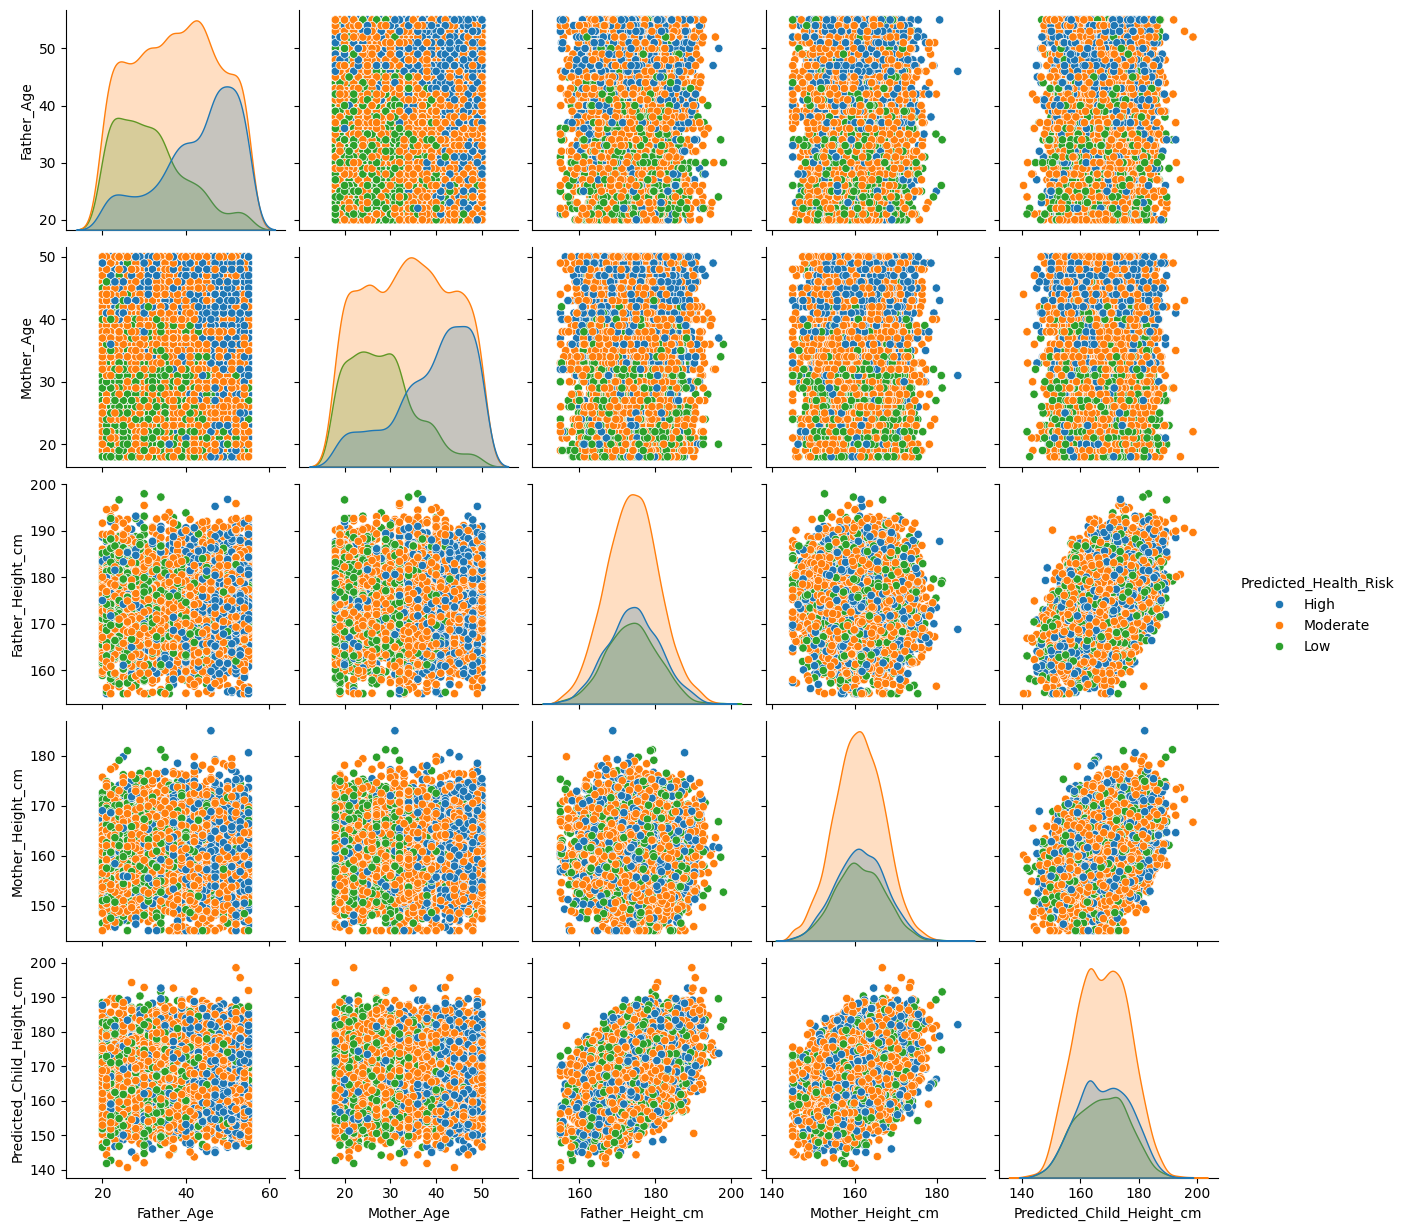

In [ ]:
sns.pairplot(df,hue="Predicted_Health_Risk")

In [ ]:
columns =['Family_ID', 'Father_Blood_Group', 'Mother_Blood_Group','Predicted_Child_Blood_Group',
       'Father_Eye_Color', 'Mother_Eye_Color', 'Father_Hair_Color',
       'Mother_Hair_Color', 'Father_Skin_Tone', 'Mother_Skin_Tone','Predicted_Health_Risk']


In [ ]:
x = df.drop(columns,axis=1)
y = df['Predicted_Health_Risk']

In [ ]:
x_onehot = pd.get_dummies(x)
x_onehot.head()

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Predicted_Child_Height_cm,Family_Disease_History_Asthma,Family_Disease_History_Diabetes,Family_Disease_History_Heart Disease,Family_Disease_History_Hypertension,Family_Disease_History_Multiple,Child_Gender_Female,Child_Gender_Male
0,48,40,163.9,168.6,161.9,False,False,False,False,True,True,False
1,34,24,185.5,152.2,164.0,False,False,False,True,False,True,False
2,27,36,178.8,158.0,162.2,False,False,False,False,True,True,False
3,40,26,161.0,157.8,161.7,False,True,False,False,False,False,True
4,38,35,175.7,160.7,171.7,True,False,False,False,False,False,True


In [ ]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)
y_int

array([0, 2, 0, ..., 2, 2, 2])

In [ ]:
y_OneHot = to_categorical(y_int)
y_OneHot

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

In [ ]:
x_onehot = x_onehot.astype(int)
x_onehot.head()

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Predicted_Child_Height_cm,Family_Disease_History_Asthma,Family_Disease_History_Diabetes,Family_Disease_History_Heart Disease,Family_Disease_History_Hypertension,Family_Disease_History_Multiple,Child_Gender_Female,Child_Gender_Male
0,48,40,163,168,161,0,0,0,0,1,1,0
1,34,24,185,152,164,0,0,0,1,0,1,0
2,27,36,178,158,162,0,0,0,0,1,1,0
3,40,26,161,157,161,0,1,0,0,0,0,1
4,38,35,175,160,171,1,0,0,0,0,0,1


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(     x_onehot, y_int, test_size=0.20, random_state=42)

In [ ]:
scaller = StandardScaler()
x_train_scal = scaller.fit_transform(x_train)
x_test_scal = scaller.transform(x_test)


In [ ]:
per = Perceptron(max_iter = 1000,random_state = 42)
per.fit(x_train_scal,y_train)


Perceptron(random_state=42)

In [ ]:
y_predict = per.predict(x_test_scal)

In [ ]:
accuracy_score(y_test,y_predict)

0.6171428571428571

In [33]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat.shape)
print(y_test_cat.shape)
print(x_train_scal.shape)
print(x_test_scal.shape)

(5600, 3)
(1400, 3)
(5600, 12)
(1400, 12)


In [60]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_train_scal.shape[1],)))

model.add(Dropout(0.3)

          )
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))


model.add(Dense(3, activation='softmax'))

In [61]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

In [62]:
history = model.fit(x_train_scal, y_train_cat, epochs=25, batch_size=32, validation_split=0.2,verbose=1)

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5951 - loss: 0.8795 - val_accuracy: 0.6964 - val_loss: 0.6935
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7132 - loss: 0.6561 - val_accuracy: 0.7330 - val_loss: 0.5722
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7359 - loss: 0.5806 - val_accuracy: 0.7420 - val_loss: 0.5440
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7442 - loss: 0.5495 - val_accuracy: 0.7402 - val_loss: 0.5412
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7493 - loss: 0.5433 - val_accuracy: 0.7411 - val_loss: 0.5368
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7513 - loss: 0.5382 - val_accuracy: 0.7446 - val_loss: 0.5398
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7647 - loss: 0.5223 - val_accuracy: 0.7375 - val_loss: 0.5387
Epoch 8/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7607 - loss: 0.5203 - val_accuracy: 0.

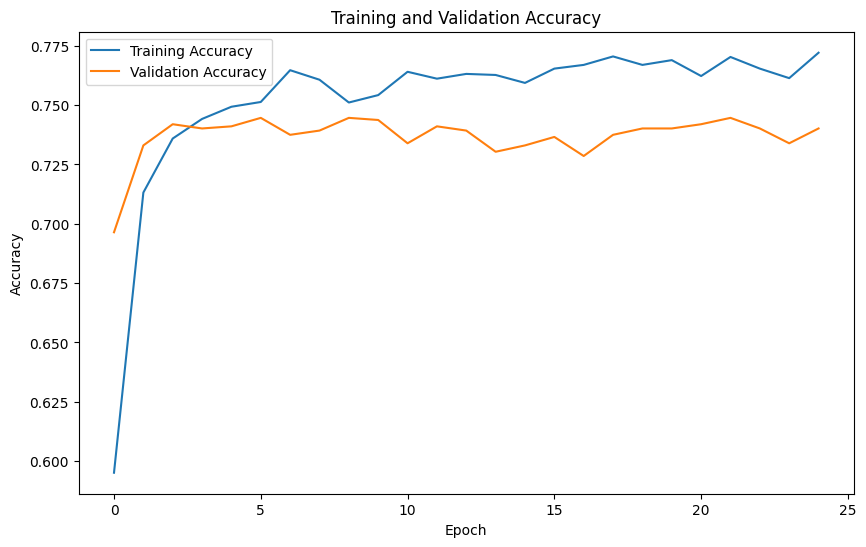

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [65]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scal, y_train)
pred = rf.predict(x_test_scal)
accuracy_score(y_test,pred)

0.765

In [66]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train_scal, y_train)
pred = xgb.predict(x_test_scal)
accuracy_score(y_test,pred)

0.7578571428571429

So I have checked with three different algorithms that the human genitical parental traits in a child is only predictable upto the max value of 77percent , while around 23percent randomness can be seen , also these randomness is dependable over changing climatic conditions over time . this randomness can also be from DNA copying error, Chromosomal crossover,Polygenic traits,Epigenitics.

Here we can also Draw a new Finding that DNA is protecting itself or better it is evolving for making the offspring survive the changing climatic and enviromental conditions